<a href="https://colab.research.google.com/github/vitorhugo28/TelecomX_BR/blob/main/TelecomX_BR_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [226]:
import pandas as pd

In [227]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

In [228]:
dados_brutos = pd.read_json(url)

In [229]:
dados_brutos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [230]:
dados_brutos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `gender`: gênero (masculino e feminino)
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `MultipleLines`: assisnatura de mais de uma linha de telefone
* `InternetService`: assinatura de um provedor internet
* `OnlineSecurity`: assinatura adicional de segurança online
* `OnlineBackup`: assinatura adicional de backup online
* `DeviceProtection`: assinatura adicional de proteção no dispositivo
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

In [231]:
df_completo = pd.json_normalize(dados_brutos.to_dict(orient='records'))

In [232]:
df_completo

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [233]:
df_completo.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

#### Dados selecionados para análise

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `InternetService`: assinatura de um provedor internet
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

In [234]:
colunas_selecionadas = [
    'customerID', 'Churn', 'customer.tenure', 'phone.PhoneService',
    'internet.InternetService', 'internet.StreamingTV', 'internet.StreamingMovies',
    'account.Contract', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total'
                       ]

dados_analise = df_completo[ colunas_selecionadas ].copy()

In [235]:
dados_analise.columns = [
    'ID_Cliente', 'Churn', 'Meses_Contrato', 'Telefone',
    'Internet', 'TV_Cabo', 'Streaming_Filmes',
    'Contrato', 'Forma_Pagamento', 'Valor_Mensal', 'Valor_Total'
]

In [236]:
dados_analise.head(5)

,ID_Cliente,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,No,9,Yes,DSL,Yes,No,One year,Mailed check,65.6,593.3
1,0003-MKNFE,No,9,Yes,DSL,No,Yes,Month-to-month,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,4,Yes,Fiber optic,No,No,Month-to-month,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,13,Yes,Fiber optic,Yes,Yes,Month-to-month,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,3,Yes,Fiber optic,Yes,No,Month-to-month,Mailed check,83.9,267.4


In [237]:
dados_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Cliente        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   Meses_Contrato    7267 non-null   int64  
 3   Telefone          7267 non-null   object 
 4   Internet          7267 non-null   object 
 5   TV_Cabo           7267 non-null   object 
 6   Streaming_Filmes  7267 non-null   object 
 7   Contrato          7267 non-null   object 
 8   Forma_Pagamento   7267 non-null   object 
 9   Valor_Mensal      7267 non-null   float64
 10  Valor_Total       7267 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 624.6+ KB


In [238]:
print("Valores nulos por coluna:")
print(dados_analise.isna().sum())

Valores nulos por coluna:
ID_Cliente          0
Churn               0
Meses_Contrato      0
Telefone            0
Internet            0
TV_Cabo             0
Streaming_Filmes    0
Contrato            0
Forma_Pagamento     0
Valor_Mensal        0
Valor_Total         0
dtype: int64


In [239]:
print(f"Linhas duplicadas: {dados_analise.duplicated().sum()}")

Linhas duplicadas: 0


In [240]:
print(f"ID duplicados: {dados_analise['ID_Cliente'].duplicated().sum()}")

ID duplicados: 0


#🔧 Transformação

In [241]:

dados_analise['Valor_Mensal'] = pd.to_numeric(dados_analise['Valor_Mensal'], errors='coerce').fillna(0)
dados_analise['Valor_Total'] = pd.to_numeric(dados_analise['Valor_Total'], errors='coerce').fillna(0)

In [242]:
dados_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Cliente        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   Meses_Contrato    7267 non-null   int64  
 3   Telefone          7267 non-null   object 
 4   Internet          7267 non-null   object 
 5   TV_Cabo           7267 non-null   object 
 6   Streaming_Filmes  7267 non-null   object 
 7   Contrato          7267 non-null   object 
 8   Forma_Pagamento   7267 non-null   object 
 9   Valor_Mensal      7267 non-null   float64
 10  Valor_Total       7267 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 624.6+ KB


In [243]:
dados_analise[['Churn', 'Telefone','TV_Cabo', 'Streaming_Filmes']] = dados_analise[['Churn', 'Telefone','TV_Cabo', 'Streaming_Filmes']].replace(r'Yes', 'Sim').replace(r'No', 'Nao')

In [244]:
dados_analise.head(5)

,ID_Cliente,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,Nao,9,Sim,DSL,Sim,Nao,One year,Mailed check,65.6,593.30
1,0003-MKNFE,Nao,9,Sim,DSL,Nao,Sim,Month-to-month,Mailed check,59.9,542.40
2,0004-TLHLJ,Sim,4,Sim,Fiber optic,Nao,Nao,Month-to-month,Electronic check,73.9,280.85
3,0011-IGKFF,Sim,13,Sim,Fiber optic,Sim,Sim,Month-to-month,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sim,3,Sim,Fiber optic,Sim,Nao,Month-to-month,Mailed check,83.9,267.40


In [245]:
dados_analise.set_index("ID_Cliente").head(5)

,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
ID_Cliente,,,,,,,,,,
0002-ORFBO,Nao,9,Sim,DSL,Sim,Nao,One year,Mailed check,65.6,593.30
0003-MKNFE,Nao,9,Sim,DSL,Nao,Sim,Month-to-month,Mailed check,59.9,542.40
0004-TLHLJ,Sim,4,Sim,Fiber optic,Nao,Nao,Month-to-month,Electronic check,73.9,280.85
0011-IGKFF,Sim,13,Sim,Fiber optic,Sim,Sim,Month-to-month,Electronic check,98.0,1237.85
0013-EXCHZ,Sim,3,Sim,Fiber optic,Sim,Nao,Month-to-month,Mailed check,83.9,267.40


#📊 Carga e análise

In [246]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

minha_paleta = ["#0FC2C0", "#0CABA8", "#008F8C", "#015958", "#023535"]
paleta_churn = {"Nao": "#0FC2C0", "Sim": "#015958"}

sns.set_palette(minha_paleta)

In [247]:
analise_estatistica = dados_analise.describe()
print(analise_estatistica.round(2))

       Meses_Contrato  Valor_Mensal  Valor_Total
count         7267.00       7267.00      7267.00
mean            32.35         64.72      2277.18
std             24.57         30.13      2268.65
min              0.00         18.25         0.00
25%              9.00         35.42       396.20
50%             29.00         70.30      1389.20
75%             55.00         89.88      3778.52
max             72.00        118.75      8684.80


In [248]:
Media_Valor_Mensal = dados_analise["Valor_Mensal"].mean()
print(f"A média do valor mensal é: R$ {Media_Valor_Mensal:.2f}")

A média do valor mensal é: R$ 64.72


In [249]:
Media_Valor_Total = dados_analise["Valor_Total"].mean()
print(f"A média do valor total é: R$ {Media_Valor_Total:.2f}")

A média do valor total é: R$ 2277.18


In [250]:
import numpy as np

Media_Meses_Contrato = np.round(dados_analise["Meses_Contrato"].mean())
print(f"A média de meses dos contratos é de {Media_Meses_Contrato:.0f} meses ")

A média de meses dos contratos é de 32 meses 


In [251]:
qtd_total_contratos = dados_analise["ID_Cliente"].count()
Valor_total_contratos = dados_analise["Valor_Total"].sum()

Churn_total_sim = (dados_analise['Churn'] == 'Sim').sum()
Valor_Churn_total_sim = dados_analise.loc[dados_analise['Churn'] == 'Sim', 'Valor_Total'].sum()

Churn_total_nao = (dados_analise['Churn'] == 'Nao').sum()
Valor_Churn_total_nao = dados_analise.loc[dados_analise['Churn'] == 'Nao', 'Valor_Total'].sum()


filtro_vazio = (dados_analise['Churn'] == '') | (dados_analise['Churn'].isna())
Churn_total_vazio = filtro_vazio.sum()
Valor_Churn_total_vazio = dados_analise.loc[filtro_vazio, 'Valor_Total'].sum()


print(f"Há um total de {qtd_total_contratos} contratos, totalizando o valor total de R$ {Valor_total_contratos:,.2f}")
print(f"Contratos ativos: {Churn_total_nao}, totalizando o valor de R${Valor_Churn_total_nao:,.2f}")
print(f"Contratos encerrados: {Churn_total_sim}, totalizando o prejuízo total de R${Valor_Churn_total_sim:,.2f}")
print(f"Contratos sem classificação: {Churn_total_vazio}, totalizando o valor de R${Valor_Churn_total_vazio:,.2f}")


Há um total de 7267 contratos, totalizando o valor total de R$ 16,548,281.85
Contratos ativos: 5174, totalizando o valor de R$13,193,241.80
Contratos encerrados: 1869, totalizando o prejuízo total de R$2,862,926.90
Contratos sem classificação: 224, totalizando o valor de R$492,113.15


In [252]:
dados_resumo = {
    'Status': ['Ativos', 'Encerrados', 'Sem Classificação'],
    'Qtd_Contratos': [Churn_total_nao, Churn_total_sim, Churn_total_vazio],
    'Valor_Financeiro (R$)': [Valor_Churn_total_nao, Valor_Churn_total_sim, Valor_Churn_total_vazio]
}


df_resumo = pd.DataFrame(dados_resumo)


df_resumo['Percentual (%)'] = (df_resumo['Qtd_Contratos'] / qtd_total_contratos * 100).round(2)

print("RESUMO EXECUTIVO DE CHURN")
display(df_resumo)

RESUMO EXECUTIVO DE CHURN


,Status,Qtd_Contratos,Valor_Financeiro (R$),Percentual (%)
0,Ativos,5174,13193241.80,71.20
1,Encerrados,1869,2862926.90,25.72
2,Sem Classificação,224,492113.15,3.08


In [253]:
colunas_servicos = [
    'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
    'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
    'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies'
]

dados_analise['Qtd_Servicos'] = df_completo[colunas_servicos].isin(['Yes', 'Fiber optic', 'DSL']).sum(axis=1)


In [254]:
ordem_desejada = [
    'ID_Cliente', 'Churn', 'Meses_Contrato', 'Telefone', 'Internet',
    'TV_Cabo', 'Streaming_Filmes', 'Qtd_Servicos', 'Contrato',
    'Forma_Pagamento', 'Valor_Mensal', 'Valor_Total'
]

In [255]:
dados_analise = dados_analise[ordem_desejada]

In [256]:
dados_analise.head(5)

,ID_Cliente,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,Nao,9,Sim,DSL,Sim,Nao,5,One year,Mailed check,65.6,593.30
1,0003-MKNFE,Nao,9,Sim,DSL,Nao,Sim,4,Month-to-month,Mailed check,59.9,542.40
2,0004-TLHLJ,Sim,4,Sim,Fiber optic,Nao,Nao,3,Month-to-month,Electronic check,73.9,280.85
3,0011-IGKFF,Sim,13,Sim,Fiber optic,Sim,Sim,6,Month-to-month,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sim,3,Sim,Fiber optic,Sim,Nao,4,Month-to-month,Mailed check,83.9,267.40


In [257]:
media_servicos = dados_analise['Qtd_Servicos'].mean()

print(f"Média de serviços por cliente: {media_servicos:.2f}")

Média de serviços por cliente: 4.14


In [258]:
Chrun_servicos = dados_analise[ dados_analise["Churn"] == "Sim"] ["Qtd_Servicos"].value_counts().reset_index(name="Quantidade Churn")

In [259]:
Chrun_servicos.head(3)

,Qtd_Servicos,Quantidade Churn
0,3,380
1,4,352
2,5,289


In [260]:
qtd_Meses_Contrato = dados_analise["Meses_Contrato"].value_counts().sort_values(ascending=False).reset_index(name='Qtd_Clientes')


In [261]:
qtd_Meses_Contrato.head(3)

,Meses_Contrato,Qtd_Clientes
0,1,634
1,72,369
2,2,246


In [262]:
churn_por_mes = dados_analise[dados_analise['Churn'] == 'Sim']['Meses_Contrato'].value_counts().sort_values(ascending=False).reset_index(name='Qtd_Churn')

In [263]:
churn_por_mes.head(3)

,Meses_Contrato,Qtd_Churn
0,1,380
1,2,123
2,3,94


In [264]:
Qtd_Churn_Servico = dados_analise[dados_analise['Churn'] == 'Sim'][["Telefone", "Internet", "TV_Cabo", "Streaming_Filmes"]].isin(['Sim', 'Fiber optic', 'DSL']).sum()

print("Quantidade de clientes que saíram e que UTILIZAVAM cada serviço:")
print(Qtd_Churn_Servico)


Quantidade de clientes que saíram e que UTILIZAVAM cada serviço:
Telefone            1699
Internet            1756
TV_Cabo              814
Streaming_Filmes     818
dtype: int64


In [265]:
Qtd_Churn_Forma_Pagamento = dados_analise[dados_analise['Churn'] == 'Sim']['Forma_Pagamento'].value_counts().reset_index(name='Qtd_Clientes')

In [266]:
Qtd_Churn_Forma_Pagamento

,Forma_Pagamento,Qtd_Clientes
0,Electronic check,1071
1,Mailed check,308
2,Bank transfer (automatic),258
3,Credit card (automatic),232


In [267]:
Qtd_Churn_Contrato = dados_analise[dados_analise['Churn'] == 'Sim']['Contrato'].value_counts().reset_index(name='Qtd_Clientes')

In [268]:
Qtd_Churn_Contrato

,Contrato,Qtd_Clientes
0,Month-to-month,1655
1,One year,166
2,Two year,48


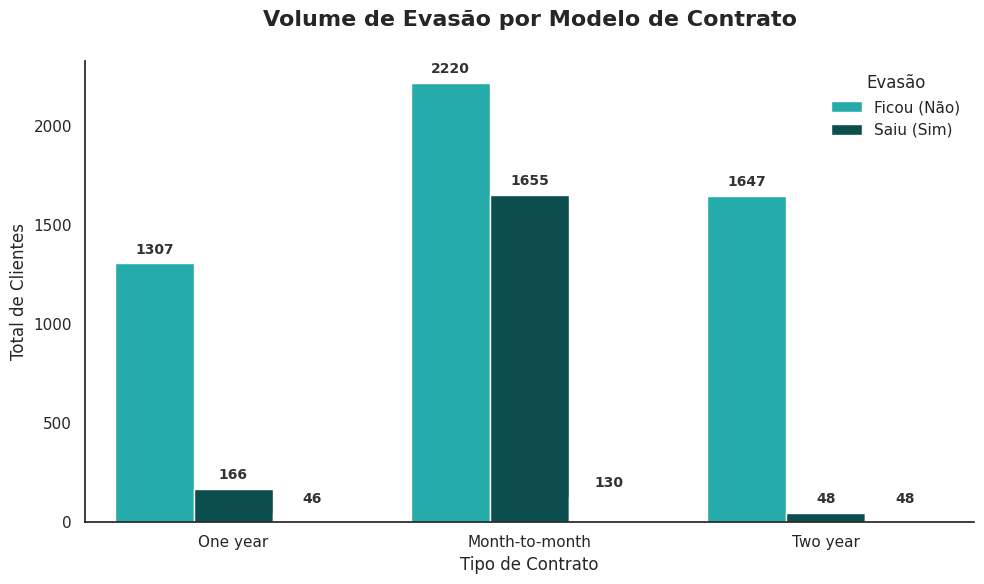

In [269]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='Contrato', hue='Churn', data=dados_analise, palette=paleta_churn)

plt.title('Volume de Evasão por Modelo de Contrato',
          fontsize=16, fontweight='bold', loc='center', pad=25)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Total de Clientes', fontsize=12)
plt.legend(title='Evasão', frameon=False, labels=['Ficou (Não)', 'Saiu (Sim)'])

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold', color='#333333')

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('evasao_contrato.png')
plt.show()

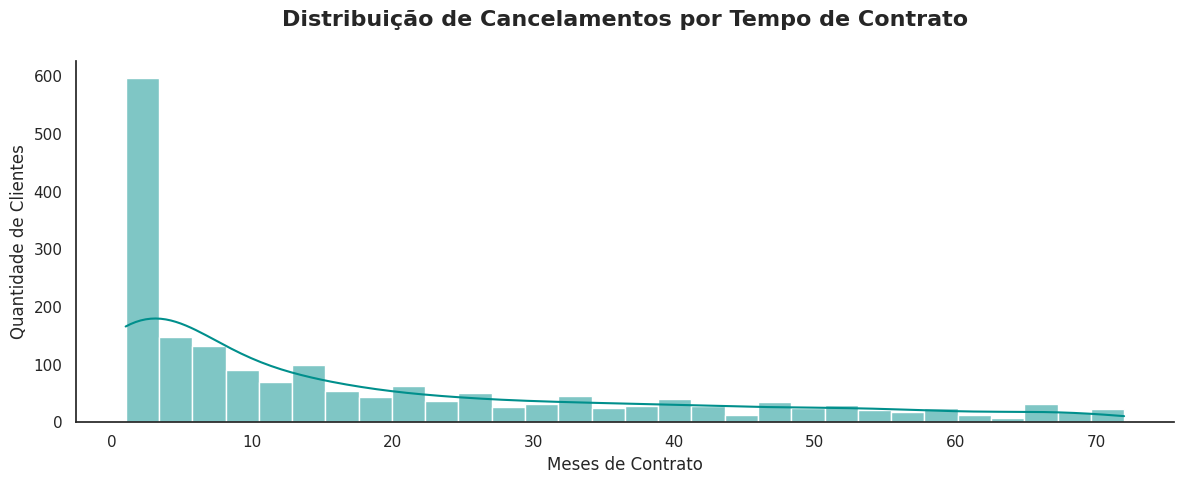

In [270]:
plt.figure(figsize=(12, 5))

ax = sns.histplot(data=dados_analise[dados_analise['Churn'] == 'Sim'],
                  x='Meses_Contrato', kde=True, color='#008F8C', bins=30)

plt.title('Distribuição de Cancelamentos por Tempo de Contrato',
          fontsize=16, fontweight='bold', loc='center', pad=25)
plt.xlabel('Meses de Contrato', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('histograma_churn.png')
plt.show()

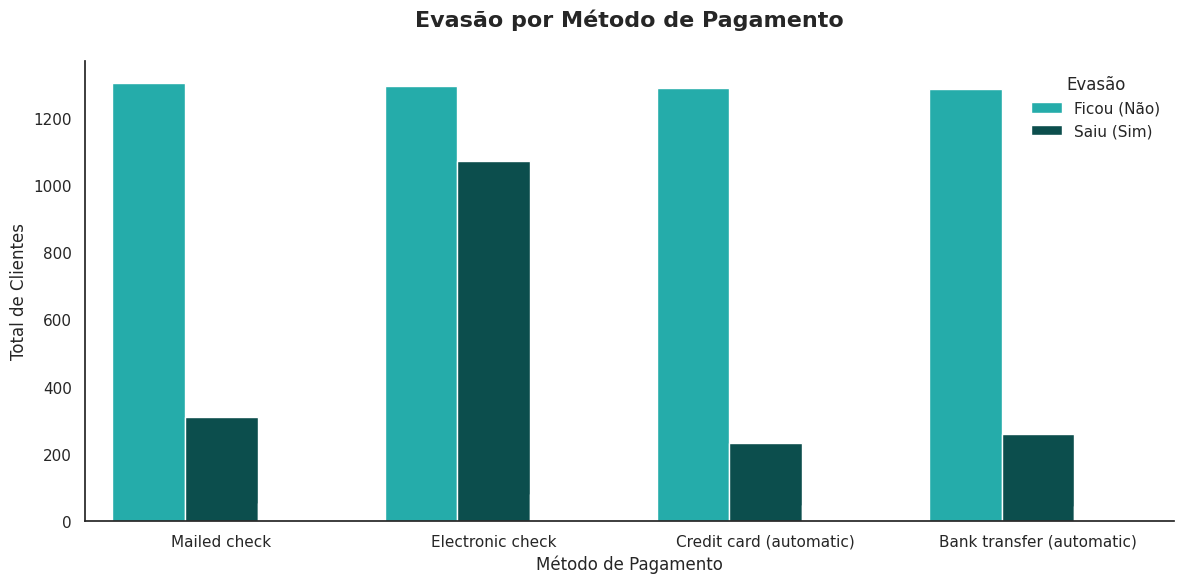

In [271]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(x='Forma_Pagamento', hue='Churn', data=dados_analise, palette=paleta_churn)

plt.title('Evasão por Método de Pagamento',
          fontsize=16, fontweight='bold', loc='center', pad=25)
plt.xlabel('Método de Pagamento', fontsize=12)
plt.ylabel('Total de Clientes', fontsize=12)
plt.legend(title='Evasão', frameon=False, labels=['Ficou (Não)', 'Saiu (Sim)'])

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('evasao_pagamento.png')
plt.show()

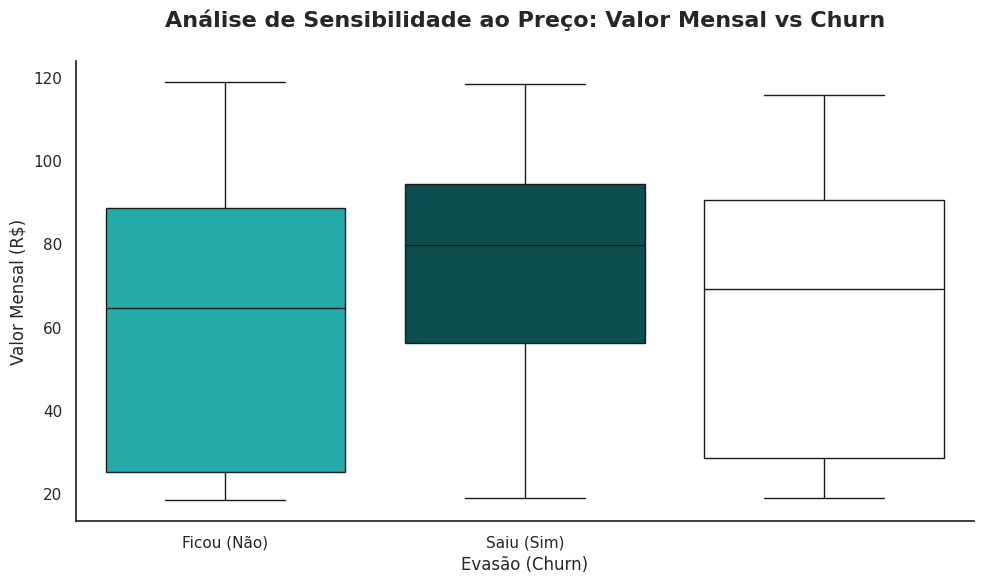

In [272]:
plt.figure(figsize=(10, 6))

ax3 = sns.boxplot(x='Churn', y='Valor_Mensal', data=dados_analise,
                  hue='Churn', palette=paleta_churn, legend=False)

plt.title('Análise de Sensibilidade ao Preço: Valor Mensal vs Churn',
          fontsize=16, fontweight='bold', loc='center', pad=25)
plt.xlabel('Evasão (Churn)', fontsize=12)
plt.ylabel('Valor Mensal (R$)', fontsize=12)

ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Ficou (Não)', 'Saiu (Sim)'])

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('boxplot_valor_mensal.png')
plt.show()

#📄Relatorio Final

# 📄 Relatório de Inteligência de Dados: Projeto Telecom X

## 1. Resumo Executivo
Este relatório apresenta os resultados da análise exploratória realizada sobre uma base de **7.267 clientes**. O objetivo principal foi identificar padrões de comportamento que levam à evasão (**Churn**) e mensurar o impacto financeiro para a empresa.

* **Taxa de Churn:** Atualmente em **25,72%**, representando **1.869 cancelamentos**.
* **Impacto Financeiro:** A evasão gerou uma perda acumulada de **R$ 2.862.926,90**.
* **Eficiência de Dados:** Foram tratados e limpos 224 registros inconsistentes para garantir a precisão das métricas.

## 2. Diagnóstico de Retenção e Ciclo de Vida
Abaixo, analisamos o comportamento temporal da evasão. Identificamos que o **Mês 1** é o período mais crítico para a operação, concentrando o maior volume de saídas (380 clientes).

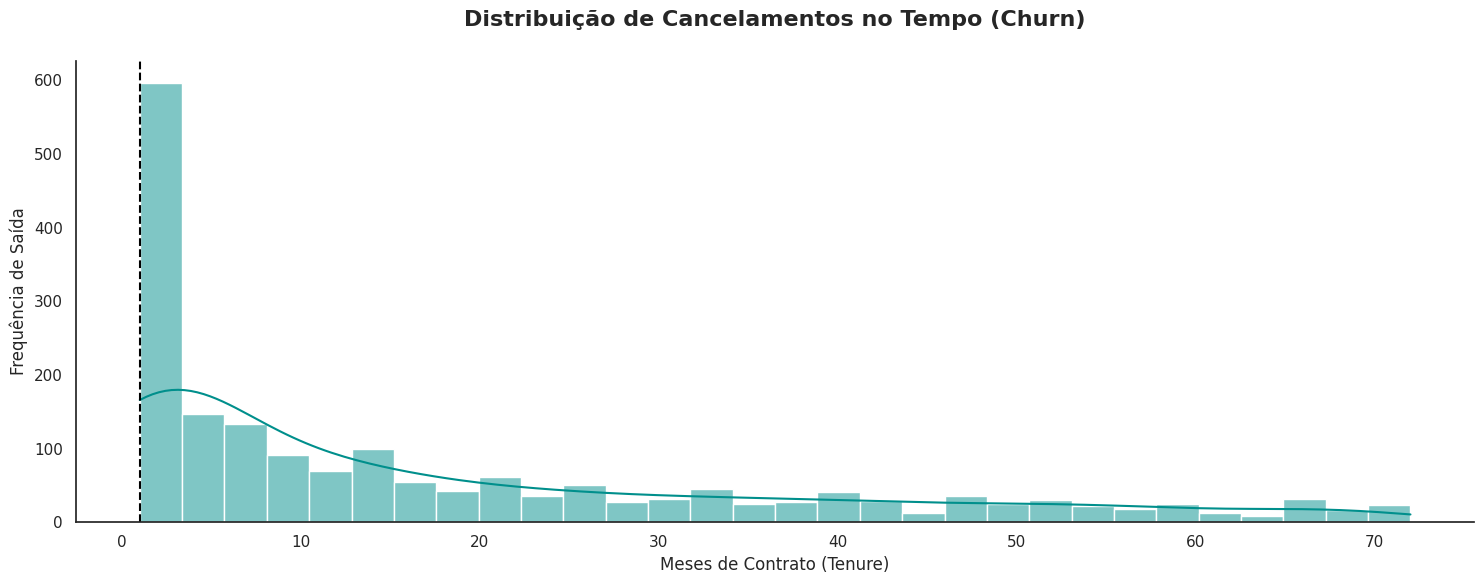

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

paleta_churn = {"Nao": "#0FC2C0", "Sim": "#015958"}

plt.figure(figsize=(15, 6))

sns.histplot(data=dados_analise[dados_analise['Churn'] == 'Sim'],
             x='Meses_Contrato', kde=True, color='#008F8C', bins=30)

plt.title('Distribuição de Cancelamentos no Tempo (Churn)', fontsize=16, fontweight='bold', loc='center', pad=25)
plt.xlabel('Meses de Contrato (Tenure)', fontsize=12)
plt.ylabel('Frequência de Saída', fontsize=12)
plt.axvline(x=1, color='black', linestyle='--')


sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()

## 3. Vulnerabilidades por Modelo de Negócio
A análise revelou que o **Tipo de Contrato** e a **Forma de Pagamento** são os principais indicadores de risco.
* **Contrato Mensal:** Responsável por **88,5%** das saídas totais.
* **Cheque Eletrônico:** Representa o método de pagamento com maior atrito, somando **1.071 casos** de churn.

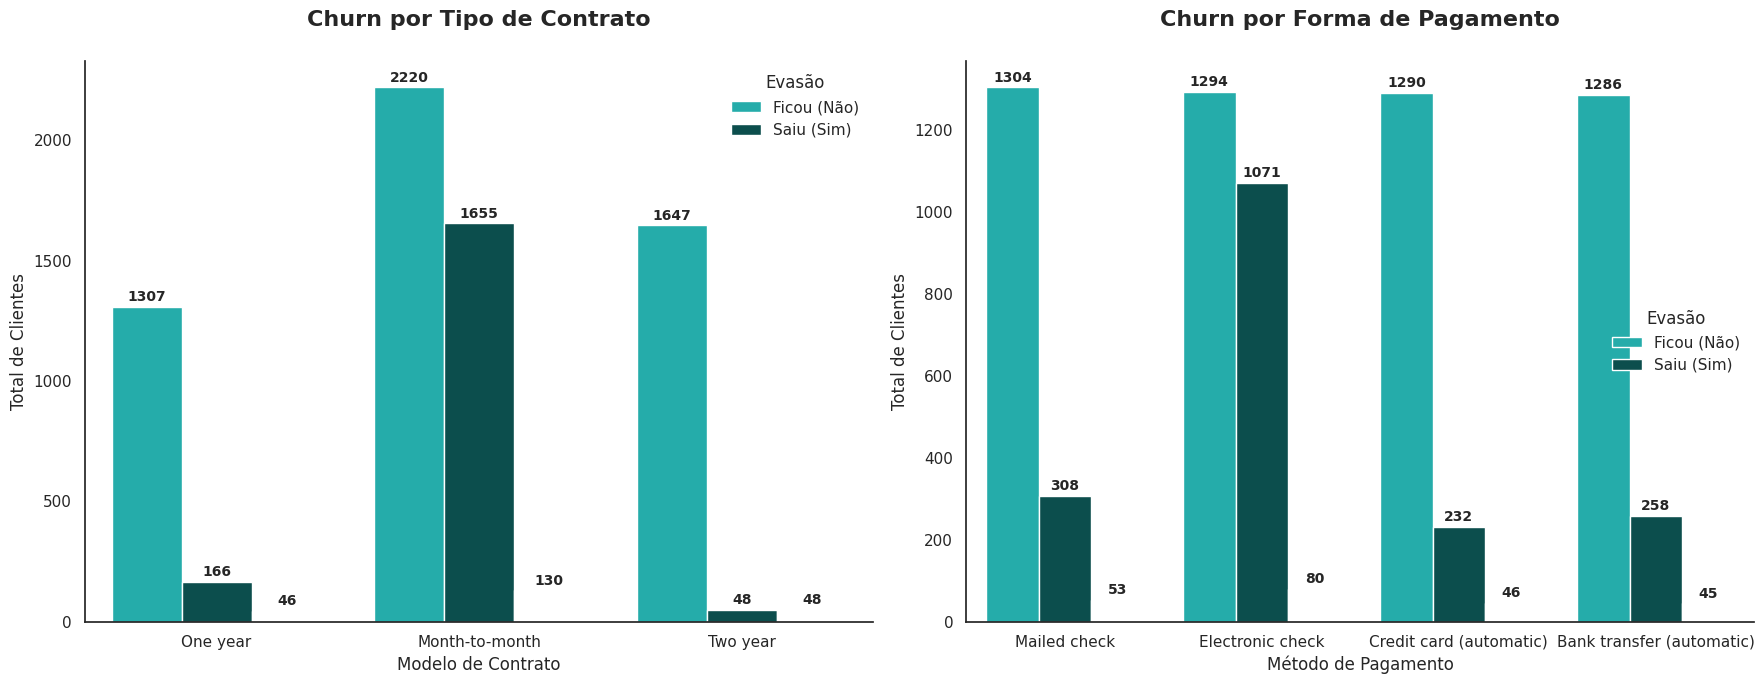

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax1 = sns.countplot(ax=axes[0], x='Contrato', hue='Churn', data=dados_analise, palette=paleta_churn)
axes[0].set_title('Churn por Tipo de Contrato', fontsize=16, fontweight='bold', loc='center', pad=25)
axes[0].set_xlabel('Modelo de Contrato', fontsize=12)
axes[0].set_ylabel('Total de Clientes', fontsize=12)
axes[0].legend(title='Evasão', frameon=False, labels=['Ficou (Não)', 'Saiu (Sim)'])

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 7), textcoords='offset points',
                     fontsize=10, fontweight='bold')

sns.despine(ax=axes[0], top=True, right=True, left=False, bottom=False)

ax2 = sns.countplot(ax=axes[1], x='Forma_Pagamento', hue='Churn', data=dados_analise, palette=paleta_churn)
axes[1].set_title('Churn por Forma de Pagamento', fontsize=16, fontweight='bold', loc='center', pad=25)
axes[1].set_xlabel('Método de Pagamento', fontsize=12)
axes[1].set_ylabel('Total de Clientes', fontsize=12)
axes[1].legend(title='Evasão', frameon=False, labels=['Ficou (Não)', 'Saiu (Sim)'])


for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 7), textcoords='offset points',
                     fontsize=10, fontweight='bold')

sns.despine(ax=axes[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

## 4. Conclusões e Próximos Passos
A base de dados foi higienizada e está pronta para a modelagem preditiva. Os principais insights extraídos sugerem:

1.  **Atenção nos Primeiros 90 Dias:** Implementar programas de boas-vindas e suporte proativo nos meses iniciais para reduzir a curva de evasão precoce identificada no histograma.
2.  **Incentivo à Migração Contratual:** Criar ofertas agressivas para converter clientes "Mês a mês" para planos anuais, reduzindo a volatilidade da base.
3.  **Modernização de Pagamento:** Estimular o uso de meios de pagamento automáticos em substituição ao cheque eletrônico, visando estabilizar a receita recorrente.
4.  **Treinamento de Machine Learning:** Utilizar as variáveis `Contrato`, `Meses_Contrato` e `Qtd_Servicos` como os principais preditores para o modelo de classificação a ser desenvolvido a seguir.

**Média de Serviços por Cliente:** 4,14 (Oportunidade de Cross-sell identified).